In [39]:
import numpy as np
import pandas as pd

In [3]:
from google.colab import files
data = files.upload()

Saving Experience-Salary.csv to Experience-Salary.csv


In [5]:
df = pd.read_csv("Experience-Salary.csv")

In [6]:
df.head()

,exp(in months),salary(in thousands)
0,18.290293,16.521825
1,17.023407,11.666234
2,26.343613,23.167255
3,19.105834,20.877145
4,27.742516,23.166236


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 2 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   exp(in months)        1000 non-null   float64
 1   salary(in thousands)  1000 non-null   float64
dtypes: float64(2)
memory usage: 15.8 KB


In [10]:
df.describe()

,exp(in months),salary(in thousands)
count,1000.000000,1000.000000
mean,26.157825,26.722597
std,8.717091,8.844761
min,0.697594,-1.276342
25%,20.073600,20.531008
50%,25.875225,26.745576
75%,32.406986,32.615753
max,49.463222,55.297016


In [17]:
df.columns = ['experience', 'salary']

In [18]:
df.isnull()

,experience,salary
0,False,False
1,False,False
2,False,False
3,False,False
4,False,False
...,...,...
995,False,False
996,False,False
997,False,False
998,False,False


In [19]:
df.isnull().sum()

,0
experience,0
salary,0


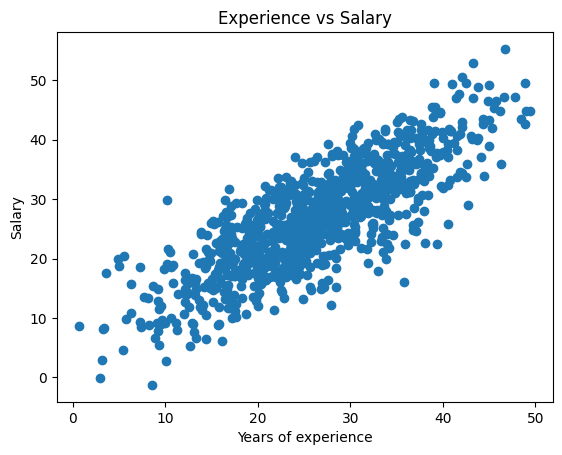

In [24]:
import matplotlib.pyplot as plt

plt.scatter(df[['experience']], df['salary'])
plt.xlabel('Years of experience')
plt.ylabel('Salary')
plt.title('Experience vs Salary')
plt.show()

In [25]:
df.corr()

,experience,salary
experience,1.000000,0.810969
salary,0.810969,1.000000


the dataset shows strong positive linear relationship between experience and salary.


In [26]:
from sklearn.model_selection import train_test_split

In [29]:
X = df[['experience']]
y = df['salary']

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state = 42)

In [32]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [34]:
model.coef_

array([0.83360799])

In [35]:
model.intercept_

np.float64(4.9111770977098494)

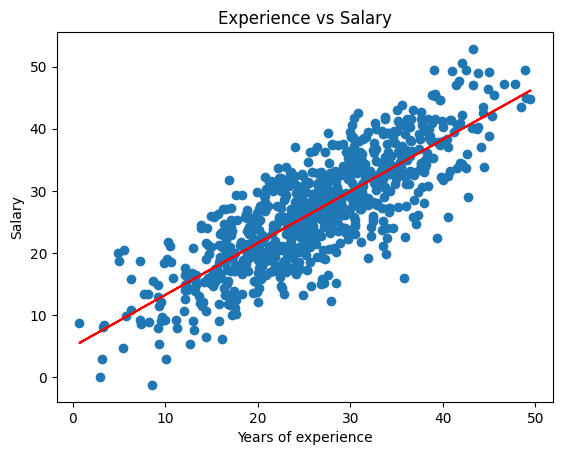

In [43]:
plt.scatter(X_train, y_train)
plt.plot(X_train, model.predict(X_train), color = 'red')

plt.xlabel('Years of experience')
plt.ylabel('Salary')
plt.title('Experience vs Salary')
plt.show()

In [53]:
from sklearn.metrics import r2_score, mean_squared_error
y_pred = model.predict(X_test)

In [57]:
print("R^2 : ", r2_score(y_test, y_pred))
print("RMSE: ", mean_squared_error(y_test,y_pred))

R^2 :  0.6208258933084713
RMSE:  27.650268732842278
